# Deduplication Experiment Analysis

This notebook analyzes the effect of SimHash-based data deduplication on model performance, comparing in-distribution (test) vs out-of-distribution (OOD) generalization.

**Key Question**: Does aggressive deduplication improve generalization to external datasets?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Experiment 1 Results
exp1_results = {
    'k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'test_auroc_mean': [0.9993, 0.9998, 0.9991, 0.9996, 0.9952, 0.9907, 0.9758, 0.9764, 0.9005, 0.8816, 0.7148, 0.7394],
    'test_auroc_std': [0.0008, 0.0001, 0.0005, 0.0004, 0.0014, 0.0029, 0.0262, 0.0093, 0.1281, 0.0779, 0.0898, 0.0063],
    'test_f1_mean': [0.9978, 0.9952, 0.9964, 0.9951, 0.9828, 0.9780, 0.9458, 0.9253, 0.7315, 0.8132, 0.7395, 0.7785],
    'test_f1_std': [0.0007, 0.0013, 0.0018, 0.0038, 0.0047, 0.0057, 0.0435, 0.0134, 0.3672, 0.0775, 0.0533, 0.0311],
    'ood_auroc_mean': [0.5083, 0.5037, 0.5067, 0.4992, 0.4990, 0.4804, 0.4818, 0.4932, 0.4774, 0.4885, 0.4855, 0.5053],
    'ood_auroc_std': [0.0096, 0.0181, 0.0120, 0.0142, 0.0087, 0.0092, 0.0049, 0.0161, 0.0057, 0.0257, 0.0162, 0.0217],
    'ood_f1_mean': [0.5203, 0.5275, 0.5380, 0.5023, 0.4966, 0.4539, 0.4644, 0.3762, 0.3531, 0.4995, 0.6185, 0.6532],
    'ood_f1_std': [0.1177, 0.0836, 0.0687, 0.1065, 0.0866, 0.0875, 0.1301, 0.1563, 0.1932, 0.0972, 0.0962, 0.0171],
}

# Dataset statistics
dataset_stats = {
    'k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'total_samples': [22030, 16684, 12671, 9086, 6495, 4490, 3041, 2000, 1335, 926, 648, 429],
    'retention_pct': [100.0, 75.7, 57.5, 41.2, 29.5, 20.4, 13.8, 9.1, 6.1, 4.2, 2.9, 1.9],
}

# Create DataFrames
df_results = pd.DataFrame(exp1_results)
df_stats = pd.DataFrame(dataset_stats)
df = pd.merge(df_results, df_stats, on='k')

print("Experiment 1 Results loaded successfully!")
print(f"K values tested: {df['k'].tolist()}")
print(f"Data retention range: {df['retention_pct'].min():.1f}% - {df['retention_pct'].max():.1f}%")

Experiment 1 Results loaded successfully!
K values tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Data retention range: 1.9% - 100.0%


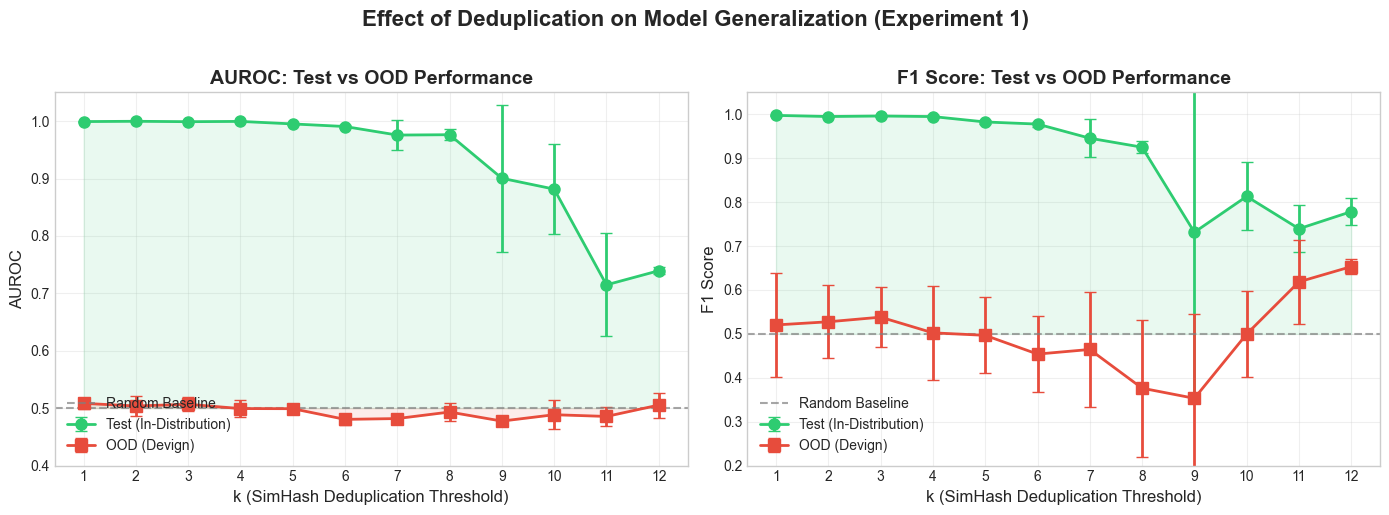


📊 Key Observation: Test performance remains high while OOD performance stays near random chance (~0.5)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AUROC - Test vs OOD
ax1 = axes[0]
ax1.errorbar(df['k'], df['test_auroc_mean'], yerr=df['test_auroc_std'], 
             marker='o', markersize=8, capsize=4, linewidth=2, label='Test (In-Distribution)', color='#2ecc71')
ax1.errorbar(df['k'], df['ood_auroc_mean'], yerr=df['ood_auroc_std'], 
             marker='s', markersize=8, capsize=4, linewidth=2, label='OOD (Devign)', color='#e74c3c')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Baseline')
ax1.fill_between(df['k'], 0.5, df['test_auroc_mean'], alpha=0.1, color='#2ecc71')
ax1.fill_between(df['k'], 0.5, df['ood_auroc_mean'], alpha=0.1, color='#e74c3c')

ax1.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax1.set_ylabel('AUROC', fontsize=12)
ax1.set_title('AUROC: Test vs OOD Performance', fontsize=14, fontweight='bold')
ax1.set_xticks(df['k'])
ax1.set_ylim(0.4, 1.05)
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: F1 Score - Test vs OOD
ax2 = axes[1]
ax2.errorbar(df['k'], df['test_f1_mean'], yerr=df['test_f1_std'], 
             marker='o', markersize=8, capsize=4, linewidth=2, label='Test (In-Distribution)', color='#2ecc71')
ax2.errorbar(df['k'], df['ood_f1_mean'], yerr=df['ood_f1_std'], 
             marker='s', markersize=8, capsize=4, linewidth=2, label='OOD (Devign)', color='#e74c3c')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random Baseline')
ax2.fill_between(df['k'], 0.5, df['test_f1_mean'], alpha=0.1, color='#2ecc71')

ax2.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('F1 Score: Test vs OOD Performance', fontsize=14, fontweight='bold')
ax2.set_xticks(df['k'])
ax2.set_ylim(0.2, 1.05)
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Effect of Deduplication on Model Generalization (Experiment 1)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp1_test_vs_ood_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key Observation: Test performance remains high while OOD performance stays near random chance (~0.5)")

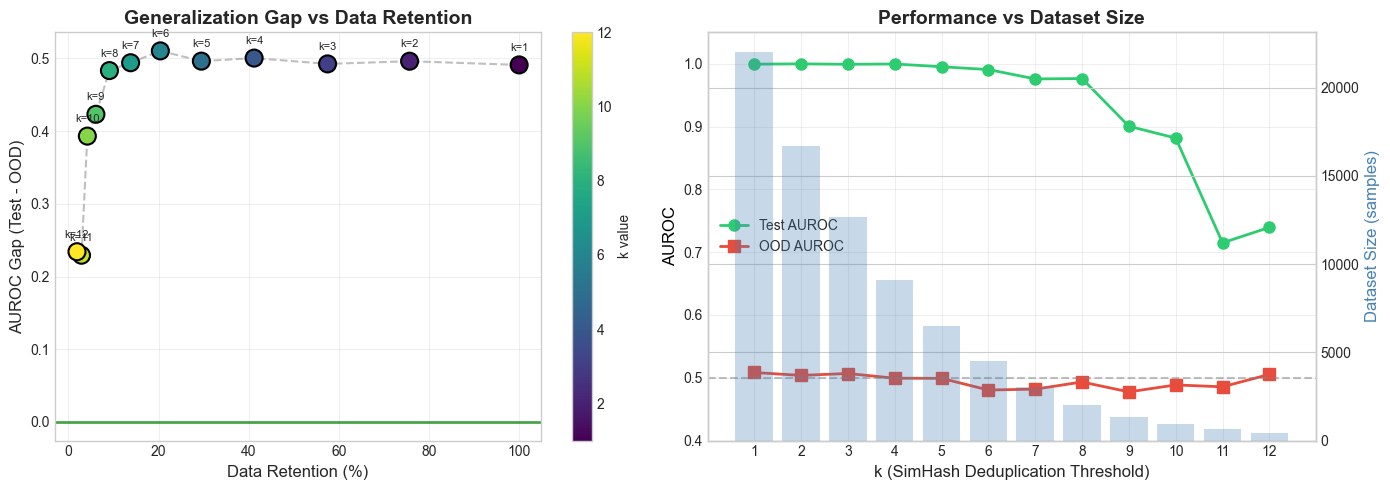


📈 Generalization Gap Range: 0.229 - 0.510
📉 Even at k=12 (98% data removed), OOD AUROC = 0.505 (still near random)


In [4]:
# Calculate generalization gap
df['auroc_gap'] = df['test_auroc_mean'] - df['ood_auroc_mean']
df['f1_gap'] = df['test_f1_mean'] - df['ood_f1_mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Generalization Gap vs Data Retention
ax1 = axes[0]
scatter = ax1.scatter(df['retention_pct'], df['auroc_gap'], c=df['k'], cmap='viridis', 
                      s=150, edgecolors='black', linewidth=1.5, zorder=3)
ax1.plot(df['retention_pct'], df['auroc_gap'], '--', alpha=0.5, color='gray', zorder=1)

# Add k labels
for idx, row in df.iterrows():
    ax1.annotate(f'k={int(row["k"])}', (row['retention_pct'], row['auroc_gap']), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

ax1.set_xlabel('Data Retention (%)', fontsize=12)
ax1.set_ylabel('AUROC Gap (Test - OOD)', fontsize=12)
ax1.set_title('Generalization Gap vs Data Retention', fontsize=14, fontweight='bold')
ax1.axhline(y=0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Perfect Generalization')
ax1.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('k value', fontsize=10)

# Plot 2: Performance vs Dataset Size
ax2 = axes[1]
ax2_twin = ax2.twinx()

line1, = ax2.plot(df['k'], df['test_auroc_mean'], 'o-', color='#2ecc71', markersize=8, 
                  linewidth=2, label='Test AUROC')
line2, = ax2.plot(df['k'], df['ood_auroc_mean'], 's-', color='#e74c3c', markersize=8, 
                  linewidth=2, label='OOD AUROC')
bars = ax2_twin.bar(df['k'], df['total_samples'], alpha=0.3, color='steelblue', label='Dataset Size')

ax2.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax2.set_ylabel('AUROC', fontsize=12, color='black')
ax2_twin.set_ylabel('Dataset Size (samples)', fontsize=12, color='steelblue')
ax2.set_title('Performance vs Dataset Size', fontsize=14, fontweight='bold')
ax2.set_xticks(df['k'])
ax2.set_ylim(0.4, 1.05)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Combined legend
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='center left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp1_generalization_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 Generalization Gap Range: {df['auroc_gap'].min():.3f} - {df['auroc_gap'].max():.3f}")
print(f"📉 Even at k=12 (98% data removed), OOD AUROC = {df[df['k']==12]['ood_auroc_mean'].values[0]:.3f} (still near random)")

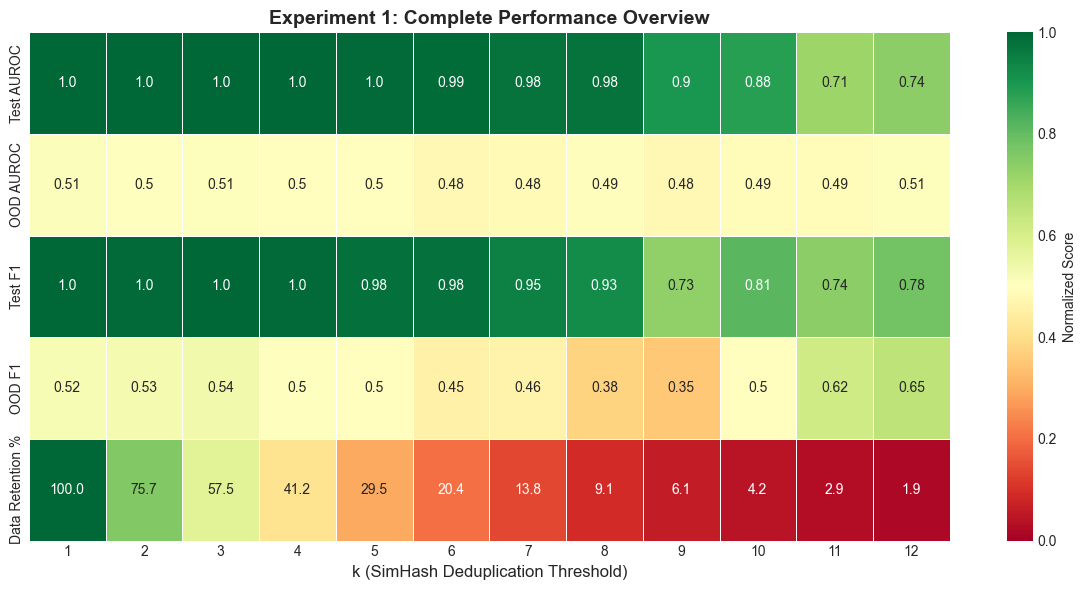

In [5]:
# Summary visualization: Heatmap of all metrics
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for heatmap
heatmap_data = df[['k', 'test_auroc_mean', 'ood_auroc_mean', 'test_f1_mean', 'ood_f1_mean', 'retention_pct']].copy()
heatmap_data = heatmap_data.set_index('k').T
heatmap_data.index = ['Test AUROC', 'OOD AUROC', 'Test F1', 'OOD F1', 'Data Retention %']

# Normalize for visualization (except retention which is already %)
heatmap_normalized = heatmap_data.copy()
heatmap_normalized.loc['Data Retention %'] = heatmap_normalized.loc['Data Retention %'] / 100

sns.heatmap(heatmap_normalized, annot=heatmap_data.round(2), fmt='', cmap='RdYlGn', 
            linewidths=0.5, ax=ax, vmin=0, vmax=1, cbar_kws={'label': 'Normalized Score'})
ax.set_xlabel('k (SimHash Deduplication Threshold)', fontsize=12)
ax.set_title('Experiment 1: Complete Performance Overview', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('exp1_performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()